# **🛡️🔒   Cybersecurity Data Cleaning and Analysis Dashboard Using Streamlit**

🚨 Description for the dataset :


  **Index / Meta**

Unnamed: 0 – Likely an index column from a previous save (can usually be dropped).

Timestamp – Date and time when the network event or attack was recorded.


**Network Addressing**

Source IP Address – IP address of the system that initiated the traffic.

Destination IP Address – IP address of the target system.

Source Port – Port number used by the source device.

Destination Port – Port number used by the destination device.


**Traffic & Packet Details**

Protocol – Network protocol used (e.g., TCP, UDP, ICMP).

Packet Length – Size of the packet in bytes.

Packet Type – Type of packet (e.g., Data, Control).

Traffic Type – Application-layer traffic category (e.g., HTTP, DNS).


**Payload & Detection Indicators**

Payload Data – Content of the packet payload (often truncated or anonymized).

Malware Indicators – Flags or signatures indicating possible malware presence.

Anomaly Scores – Numerical score representing how unusual the traffic is.

Alerts/Warnings – Security alerts generated for the event.


**Attack Information**

Attack Type – Category of attack (e.g., DDoS, Phishing, Malware).

Attack Signature – Known pattern or signature used to identify the attack.

Action Taken – Response performed (e.g., Blocked, Allowed, Logged).

Severity Level – Risk level assigned (e.g., Low, Medium, High, Critical).


**User & Network Context**

User Information – Details about the user involved (often anonymized).

Network Segment – Network zone where the event occurred (e.g., DMZ, Internal).

Geo-location Data – Geographic info derived from IP address.

Proxy Information – Indicates whether a proxy was used.


**Security Logs & Sources**

Firewall Logs – Firewall-related log entries.

IDS/IPS Alerts – Intrusion Detection/Prevention System alerts.

Log Source – Origin of the log (e.g., Firewall, Server).


**Client Environment**

Browser – Browser used by the client (e.g., Mozilla).

Device/OS – Operating system or device type (e.g., Windows, Macintosh).


**Extracted Time Features**
**bold text**
(Useful for time-series analysis and attack pattern detection)

Year

Month

Day

Hour

Minute

Second

DayOfWeek – Numeric day of the week (e.g., 0 = Monday).

#  🤖 Goal

🎯
🧠 This project focuses on building a real-world cybersecurity attack detection system using machine learning. The system performs automated data ingestion, cleaning, and exploratory analysis to understand attack patterns and network behavior. Several classification models were trained and evaluated to predict attack types and severity levels. A real-time prediction module was implemented to analyze both individual inputs and uploaded datasets. The solution is deployed through an interactive Streamlit dashboard, enabling efficient threat detection and decision-making in practical cybersecurity environments.  

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('messy_cybersecurity_attacks.csv')
print(df)

       Unnamed: 0              Timestamp Source IP Address  \
0             NaN   2023-05-30 06:33:58     103.216.15.12    
1             1.0                      ?   78.199.217.198    
2             2.0   2022-11-13 08:23:25      63.79.210.48    
3             3.0   2023-07-02 10:38:46               nan    
4             4.0   2023-07-16 13:11:07     71.166.185.76    
...           ...                    ...               ...   
39995     39995.0                   nan      26.36.109.26    
39996     39996.0   2023-03-27 00:38:27      17.21.163.81    
39997         NaN   2022-03-31 01:45:49     162.35.217.57    
39998     39998.0   2023-09-22 18:32:38               nan    
39999     39999.0   2023-10-10 11:59:52               nan    

      Destination IP Address  Source Port  Destination Port Protocol  \
0              84.9.164.252       31225.0             17616     ICMP   
1            66.191.137.154           NaN             48166     ICMP   
2                       nan       16811

# Preview Data

In [38]:
df.head()

,Unnamed: 0,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,...,Log Source,Browser,Device/OS,Year,Month,Day,Hour,Minute,Second,DayOfWeek
0,NaN,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225.0,17616,ICMP,503,Data,HTTP,...,Server,Mozilla,Windows,2023,5,30,6,33,58,1
1,1.0,?,78.199.217.198,66.191.137.154,NaN,48166,ICMP,1174,Data,HTTP,...,Firewall,Mozilla,Windows,2020,8,26,7,8,30,2
2,2.0,2022-11-13 08:23:25,63.79.210.48,nan,16811.0,53600,UDP,306,Control,HTTP,...,Firewall,Mozilla,Windows,2022,11,13,8,23,25,6
3,3.0,2023-07-02 10:38:46,nan,101.228.192.255,20018.0,32534,UDP,385,Data,HTTP,...,Firewall,Mozilla,Macintosh,2023,7,2,10,38,46,6
4,4.0,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131.0,26646,TCP,1462,Data,DNS,...,Firewall,Mozilla,Windows,2023,7,16,13,11,7,6


# Shape of Dataset

In [39]:
df.shape


(40000, 34)

# Column Names

In [40]:
df.columns

Index(['Unnamed: 0', 'Timestamp', 'Source IP Address',
       'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol',
       'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data',
       'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings',
       'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level',
       'User Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'Browser', 'Device/OS', 'Year', 'Month', 'Day', 'Hour', 'Minute',
       'Second', 'DayOfWeek'],
      dtype='object')

# Data type & Missing Value

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              35999 non-null  float64
 1   Timestamp               40000 non-null  object 
 2   Source IP Address       40000 non-null  object 
 3   Destination IP Address  40000 non-null  object 
 4   Source Port             36000 non-null  float64
 5   Destination Port        40000 non-null  int64  
 6   Protocol                40000 non-null  object 
 7   Packet Length           40000 non-null  int64  
 8   Packet Type             40000 non-null  object 
 9   Traffic Type            40000 non-null  object 
 10  Payload Data            40000 non-null  object 
 11  Malware Indicators      40000 non-null  object 
 12  Anomaly Scores          40000 non-null  float64
 13  Alerts/Warnings         40000 non-null  object 
 14  Attack Type             40000 non-null

# Remove Useless Index Column

In [42]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


In [43]:
print(df.columns)


Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information', 'Network Segment',
       'Geo-location Data', 'Proxy Information', 'Firewall Logs',
       'IDS/IPS Alerts', 'Log Source', 'Browser', 'Device/OS', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'DayOfWeek'],
      dtype='object')


# Convert to datetime

In [44]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [45]:
df['Timestamp'].dtype

dtype('<M8[ns]')

In [46]:
df['Timestamp'].head()

,Timestamp
0,2023-05-30 06:33:58
1,NaT
2,2022-11-13 08:23:25
3,2023-07-02 10:38:46
4,2023-07-16 13:11:07


# Fill NaT with the mean datetime

In [47]:
df['Timestamp'] = df['Timestamp'].fillna(df['Timestamp'].mean)

In [48]:
df['Timestamp'].head()

,Timestamp
0,2023-05-30 06:33:58
1,<bound method Series.mean of 0 2023-05-3...
2,2022-11-13 08:23:25
3,2023-07-02 10:38:46
4,2023-07-16 13:11:07


# Handle missing timestamps

In [49]:
df = df.dropna(subset=['Timestamp'])


# Clean Port Numbers

In [50]:
print(df['Source IP Address'])

0          103.216.15.12 
1         78.199.217.198 
2           63.79.210.48 
3                    nan 
4          71.166.185.76 
               ...       
39995       26.36.109.26 
39996       17.21.163.81 
39997      162.35.217.57 
39998                nan 
39999                nan 
Name: Source IP Address, Length: 40000, dtype: object


In [51]:
df['Source IP Address'] = df['Source IP Address'].astype(str)
df['Source IP Address'] = df['Source IP Address'].str.strip().replace('nan', 'Unknown')
df['Source IP Address'].head()

,Source IP Address
0,103.216.15.12
1,78.199.217.198
2,63.79.210.48
3,Unknown
4,71.166.185.76


In [52]:
df['Destination IP Address'] = df['Destination IP Address'].astype(str)
df['Destination IP Address'] = df['Destination IP Address'].str.strip().replace('nan','Unknown')
df['Destination IP Address'].head()

,Destination IP Address
0,84.9.164.252
1,66.191.137.154
2,Unknown
3,101.228.192.255
4,189.243.174.238


# Clean Protocol & Traffic Type

In [53]:
df['Protocol'] = df['Protocol'].fillna(df['Protocol'].mode()[0])

In [54]:
df['Traffic Type'] = df['Traffic Type'].fillna('Unknown')
df['Traffic Type']

,Traffic Type
0,HTTP
1,HTTP
2,HTTP
3,HTTP
4,DNS
...,...
39995,HTTP
39996,HTTP
39997,DNS
39998,FTP


# Clean Packet & Numerical Columns

In [55]:
df['Packet Length'].dtype
df['Packet Length'].head()

,Packet Length
0,503
1,1174
2,306
3,385
4,1462


In [56]:
df['Anomaly Scores'].dtype

dtype('float64')

In [57]:
df['Attack Type']

,Attack Type
0,Malware
1,Malware
2,DDoS
3,Malware
4,DDoS
...,...
39995,DDoS
39996,DDoS
39997,DDoS
39998,Malware


# Drop High-Noise Columns (Optional but Realistic)

In [58]:
drop_cols = [
    'Payload Data',
    'Firewall Logs',
    'IDS/IPS Alerts',
    'User Information'
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace= True)

In [59]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             36000 non-null  float64
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Malware Indicators      40000 non-null  object 
 10  Anomaly Scores          40000 non-null  float64
 11  Alerts/Warnings         40000 non-null  object 
 12  Attack Type             40000 non-null  object 
 13  Attack Signature        40000 non-null  object 
 14  Action Taken            40000 non-null

,0
Timestamp,0
Source IP Address,0
Destination IP Address,0
Source Port,4000
Destination Port,0
Protocol,0
Packet Length,0
Packet Type,0
Traffic Type,0
Malware Indicators,0


In [60]:
df['Source Port'].fillna(0, inplace=True)

print(df['Source Port'])

0        31225.0
1            0.0
2        16811.0
3        20018.0
4         6131.0
          ...   
39995    31005.0
39996        0.0
39997    22505.0
39998    20013.0
39999    50137.0
Name: Source Port, Length: 40000, dtype: float64


/tmp/ipython-input-3479135448.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Source Port'].fillna(0, inplace=True)


In [61]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  float64
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Malware Indicators      40000 non-null  object 
 10  Anomaly Scores          40000 non-null  float64
 11  Alerts/Warnings         40000 non-null  object 
 12  Attack Type             40000 non-null  object 
 13  Attack Signature        40000 non-null  object 
 14  Action Taken            40000 non-null

,0
Timestamp,0
Source IP Address,0
Destination IP Address,0
Source Port,0
Destination Port,0
Protocol,0
Packet Length,0
Packet Type,0
Traffic Type,0
Malware Indicators,0


In [62]:
import pandas as pd
df = pd.read_csv('messy_cybersecurity_attacks.csv')
attack_count = df["Attack Type"].value_counts().reset_index()
attack_count.columns = ["Attack Type", "Count"]
attack_count

,Attack Type,Count
0,DDoS,13428
1,Malware,13307
2,Intrusion,13265


In [63]:
df["state"] = df["Geo-location Data"].str.split(",").str[-1].str.strip()
print(df['state'])

0                   Sikkim
1                 Nagaland
2                Rajasthan
3                Rajasthan
4                  Tripura
               ...        
39995              Manipur
39996              Mizoram
39997     Himachal Pradesh
39998    Arunachal Pradesh
39999          West Bengal
Name: state, Length: 40000, dtype: object


In [64]:
from google.colab import files
import pandas as pd

df.to_csv('cleanned_cybersecurity.csv', index = False)
files.download('cleanned_cybersecurity.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 EXPLORATORY DATA ANALYSIS (EDA)

*📊* SLIDE 1: Executive Security Overview (Main Page)

🎯 Purpose
High-level snapshot for management / CISO


Attack Type Distribution

/tmp/ipython-input-4110720569.py:28: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


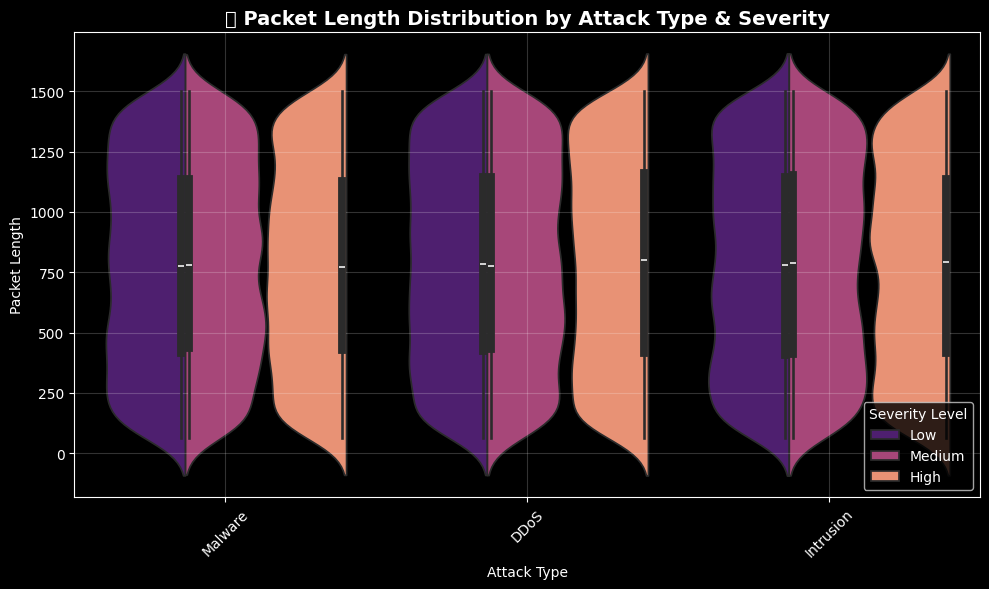

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dark style
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Attack Type",
    y="Packet Length",
    hue="Severity Level",
    split=True,
    palette="magma"   # Better for dark theme
)

plt.title("🛡 Packet Length Distribution by Attack Type & Severity",
          fontsize=14, fontweight="bold", color="white")

plt.xlabel("Attack Type", color="white")
plt.ylabel("Packet Length", color="white")

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


/tmp/ipython-input-1893530529.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1893530529.py:27: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


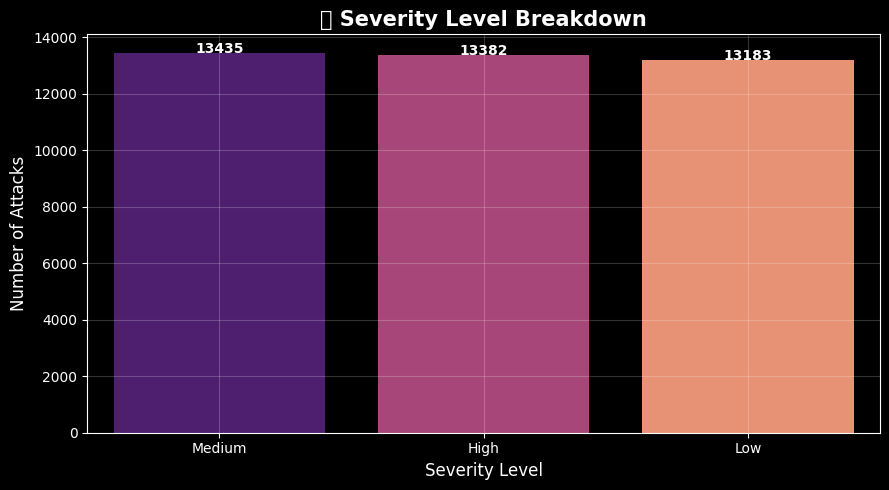

In [71]:


# Create severity counts
severity_counts = df["Severity Level"].value_counts()

# Dark background style
plt.style.use("dark_background")

plt.figure(figsize=(9,5))

sns.barplot(
    x=severity_counts.index,
    y=severity_counts.values,
    palette="magma"
)

plt.title("🛡️ Severity Level Breakdown", fontsize=15, fontweight="bold", color="white")
plt.xlabel("Severity Level", fontsize=12, color="white")
plt.ylabel("Number of Attacks", fontsize=12, color="white")

# Add value labels
for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 2, str(v), ha='center', color="white", fontweight="bold")

plt.xticks(color="white")
plt.yticks(color="white")

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


In [72]:
print(df['Risk Status'])

0          Open
1        Closed
2          Open
3        Closed
4        Closed
          ...  
39995      Open
39996      Open
39997    Closed
39998      Open
39999      Open
Name: Risk Status, Length: 40000, dtype: object


/tmp/ipython-input-2006874465.py:51: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


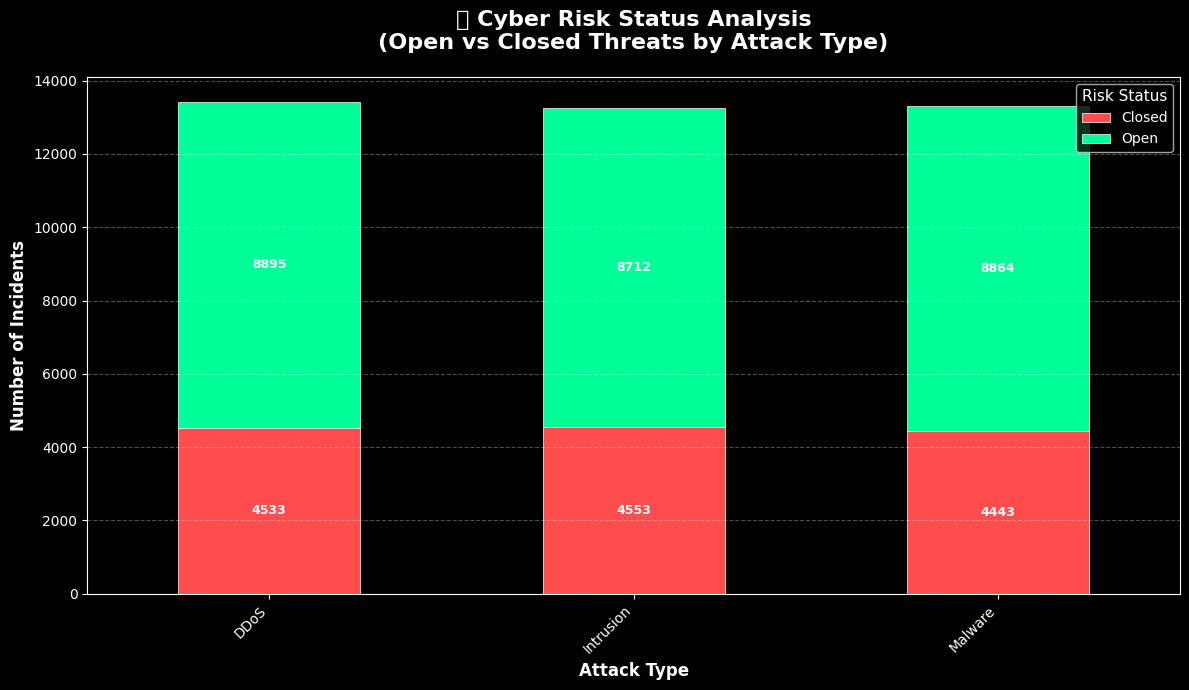

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dark theme
plt.style.use("dark_background")

# Clean column names (important)
df.columns = df.columns.str.strip()

# Create 'Risk Status' column based on 'Action Taken'
df['Risk Status'] = df['Action Taken'].apply(lambda x: 'Closed' if x == 'Blocked' else 'Open')

# Create cross-tab
risk_data = pd.crosstab(df["Attack Type"], df["Risk Status"])

# Custom cyber colors
colors = ["#ff4c4c", "#00ff99"]   # Red = Open, Green = Closed

# Create figure
fig, ax = plt.subplots(figsize=(12,7))

# Plot stacked bars
risk_data.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)

# Add value labels inside bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontsize=9, fontweight='bold')

# Styling
ax.set_title("🛡 Cyber Risk Status Analysis\n(Open vs Closed Threats by Attack Type)",
             fontsize=16,
             fontweight="bold",
             pad=20)

ax.set_xlabel("Attack Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Incidents", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(title="Risk Status", title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()

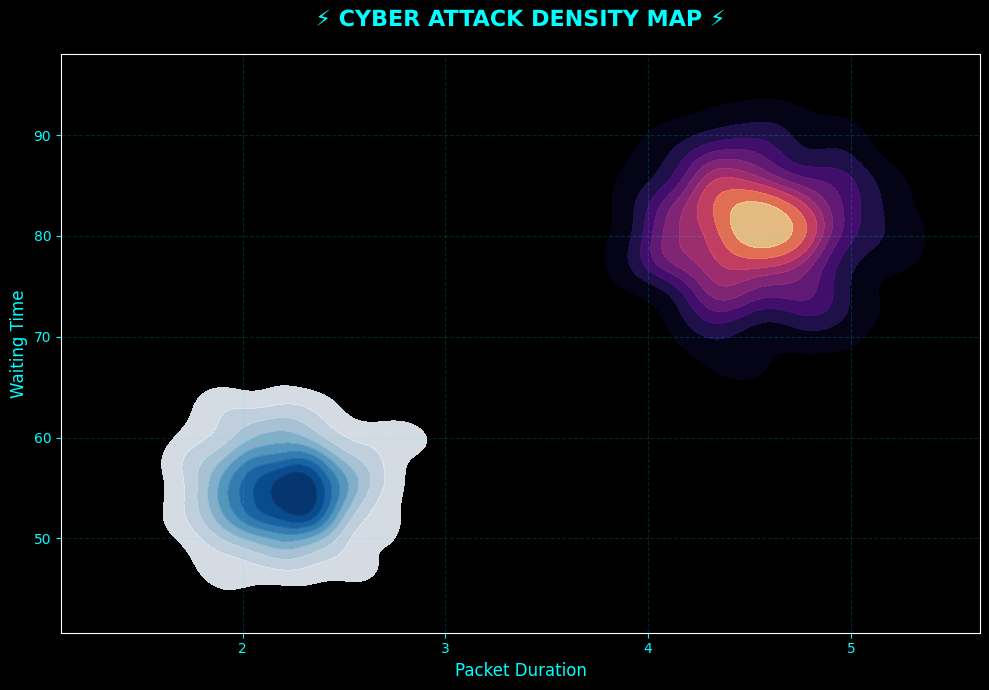

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects

# -----------------------------
# Generate Clean Cluster Data
# -----------------------------
np.random.seed(42)

short_duration = np.random.normal(2.2, 0.25, 300)
short_waiting  = np.random.normal(55, 4, 300)

long_duration = np.random.normal(4.5, 0.3, 300)
long_waiting  = np.random.normal(80, 5, 300)

df_short = pd.DataFrame({
    "duration": short_duration,
    "waiting": short_waiting,
    "kind": "LOW RISK"
})

df_long = pd.DataFrame({
    "duration": long_duration,
    "waiting": long_waiting,
    "kind": "HIGH RISK"
})

df = pd.concat([df_short, df_long])

# -----------------------------
# Create Black Cyber Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(10,7))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Neon Blue (Low Risk)
sns.kdeplot(
    data=df[df["kind"]=="LOW RISK"],
    x="duration",
    y="waiting",
    fill=True,
    cmap="Blues",
    alpha=0.9,
    thresh=0.05,
    ax=ax
)

# Neon Pink (High Risk)
sns.kdeplot(
    data=df[df["kind"]=="HIGH RISK"],
    x="duration",
    y="waiting",
    fill=True,
    cmap="magma",
    alpha=0.9,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# Cyber Styling
# -----------------------------
title = ax.set_title(
    "⚡ CYBER ATTACK DENSITY MAP ⚡",
    fontsize=16,
    fontweight="bold",
    color="#00ffff",
    pad=20
)

# Glow effect on title
title.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])

ax.set_xlabel("Packet Duration", color="#00ffff", fontsize=12)
ax.set_ylabel("Waiting Time", color="#00ffff", fontsize=12)

ax.tick_params(colors="#00ffff")

# Neon grid
ax.grid(color="#00ffff", alpha=0.15, linestyle="--")

plt.tight_layout()
plt.show()


🧠 SLIDE 2: Threat & Attack Analysis


🎯 Purpose

 Understand what type of attacks are happening and trends

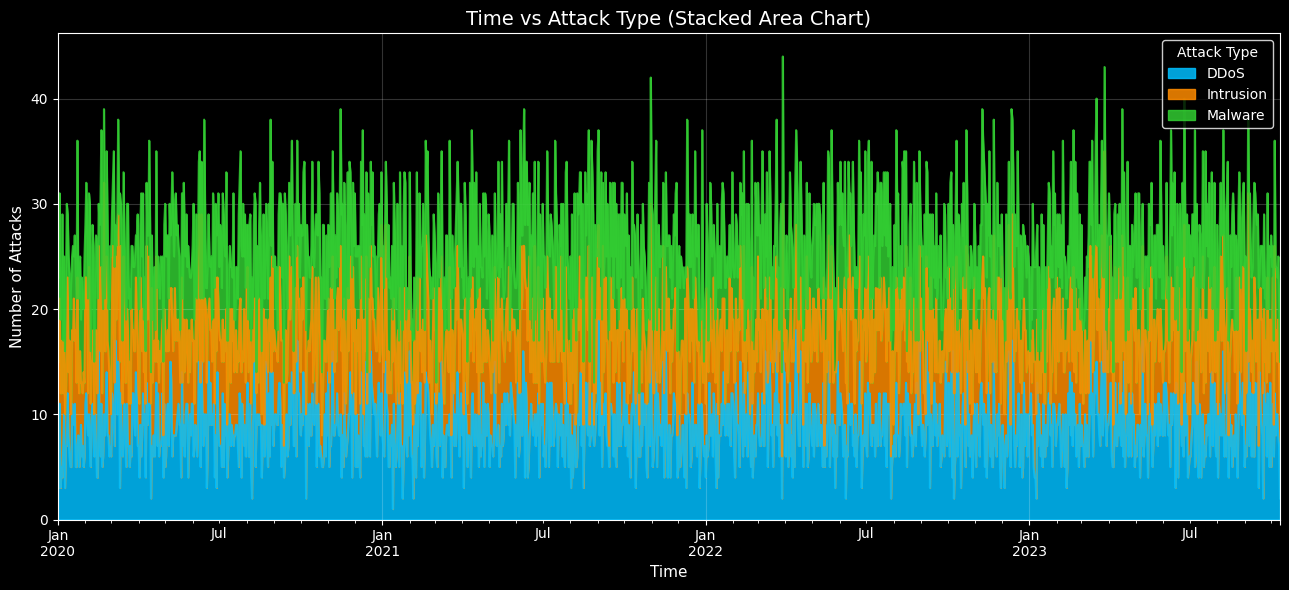

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Dark background style
plt.style.use("dark_background")

# Reload the cleaned data as df was overwritten
df = pd.read_csv("cleanned_cybersecurity.csv")

# Convert time column to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"])

# Group by time & attack type (count)
area_df = (
    df.groupby([pd.Grouper(key="Timestamp", freq="D"), "Attack Type"])
      .size()
      .unstack(fill_value=0)
)

# Custom attractive colors
colors = ["#00BFFF", "#FF8C00", "#32CD32"]  # blue, orange, green

# Plot stacked area
ax = area_df.plot(
    kind="area",
    figsize=(13,6),
    alpha=0.85,
    color=colors
)

# Titles & labels
ax.set_title("Time vs Attack Type (Stacked Area Chart)", fontsize=14, color="white")
ax.set_xlabel("Time", fontsize=11, color="white")
ax.set_ylabel("Number of Attacks", fontsize=11, color="white")

# Grid (soft)
ax.grid(True, alpha=0.2)

# Legend
ax.legend(title="Attack Type", facecolor="black", edgecolor="white")

plt.tight_layout()
plt.show()

# Anomaly Scores by Attack Type

/tmp/ipython-input-563855545.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


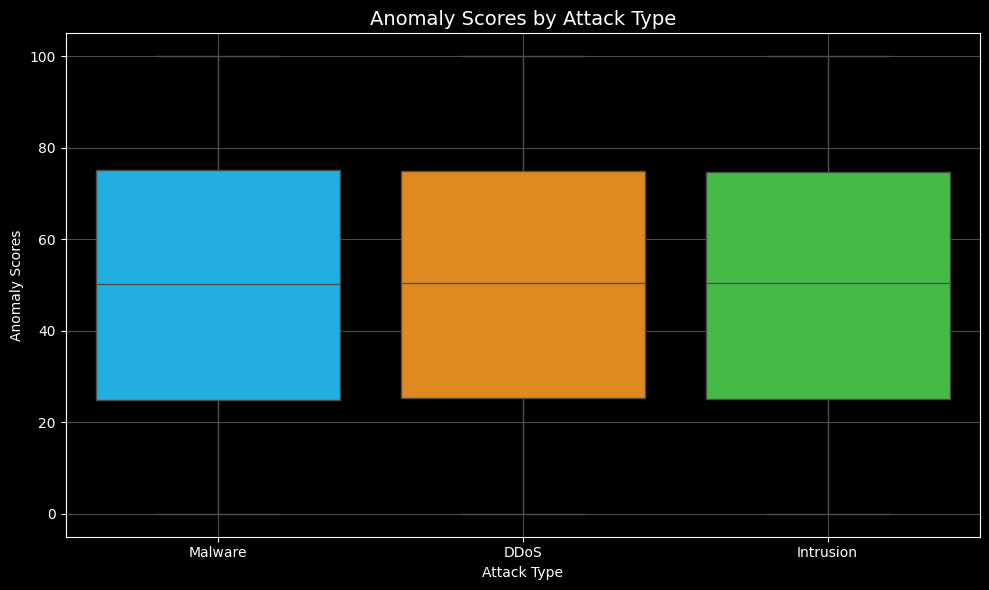

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

# Box plot
sns.boxplot(
    data=df,
    x="Attack Type",
    y="Anomaly Scores",
    palette=["#00BFFF", "#FF8C00", "#32CD32"]
)

plt.title("Anomaly Scores by Attack Type", fontsize=14)
plt.xlabel("Attack Type")
plt.ylabel("Anomaly Scores")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Anomaly Score Distribution by Severity**

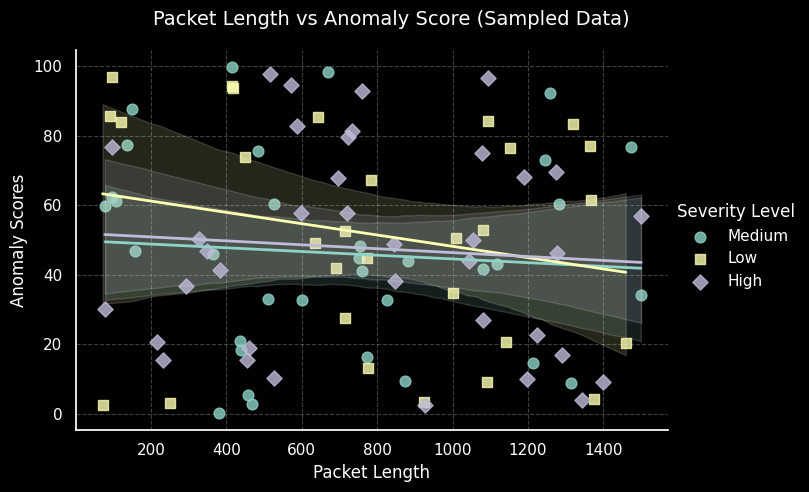

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample 100 rows
df_sample = df.sample(100, random_state=42)

# Dark theme
sns.set_theme(style="darkgrid")
plt.style.use("dark_background")

# Plot
g = sns.lmplot(
    data=df_sample,
    x="Packet Length",
    y="Anomaly Scores",
    hue="Severity Level",
    height=5,
    aspect=1.4,
    markers=["o", "s", "D"],
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"linewidth": 2}
)

# Labels
g.set_axis_labels("Packet Length", "Anomaly Scores")
g.fig.suptitle("Packet Length vs Anomaly Score (Sampled Data)", fontsize=14)
g.fig.subplots_adjust(top=0.9)

# Light grid lines
for ax in g.axes.flat:
    ax.grid(color="white", linestyle="--", linewidth=0.8, alpha=0.25)

plt.show()


# SLIDE 3 – Network & Geo Threat Intelligence

In [79]:
pip install pandas plotly


In [80]:
import plotly.express as px

fig = px.treemap(
    df,
    path=["Attack Type", "Action Taken"],
    color="Action Taken",
    hover_data=["Severity Level", "Anomaly Scores"],
    title="Attack Distribution: Attack Type → Action Taken",
    color_discrete_sequence=px.colors.qualitative.Bold  # neon style
)

# Dark theme layout
fig.update_layout(
    template="plotly_dark",
    title_font_size=20,
    title_x=0.5,
    margin=dict(t=50, l=10, r=10, b=10)
)

# Better labels & hover
fig.update_traces(
    textinfo="label+percent parent",
    textfont_size=12,
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Count: %{value}<br>"
        "Parent: %{parent}<br>"
        "<extra></extra>"
    )
)

fig.show()


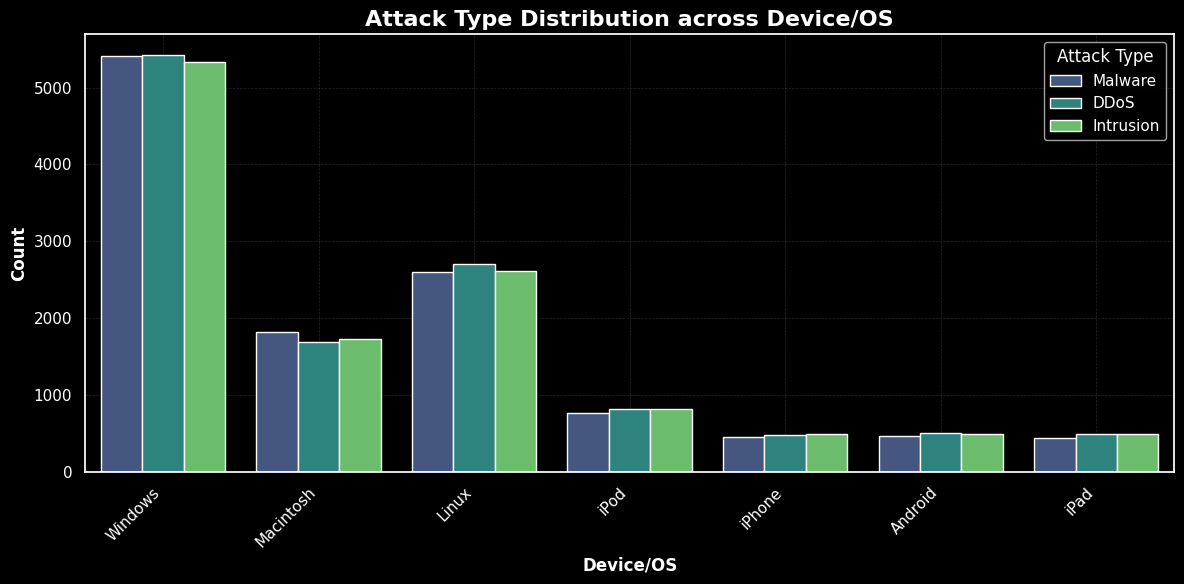

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme style
plt.style.use("dark_background")

# Set figure size
plt.figure(figsize=(12,6))

# Create countplot with attractive color palette
sns.countplot(
    data=df,
    x="Device/OS",
    hue="Attack Type",
    palette="viridis"   # You can try: "viridis", "rocket", "coolwarm"
)

# Title styling
plt.title(
    "Attack Type Distribution across Device/OS",
    fontsize=16,
    fontweight="bold",
    color="white"
)

# Axis styling
plt.xlabel("Device/OS", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")

# Rotate x labels
plt.xticks(rotation=45, ha="right")

# Grid styling
plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.3)

# Tight layout
plt.tight_layout()

plt.show()


/tmp/ipython-input-1917446403.py:11: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



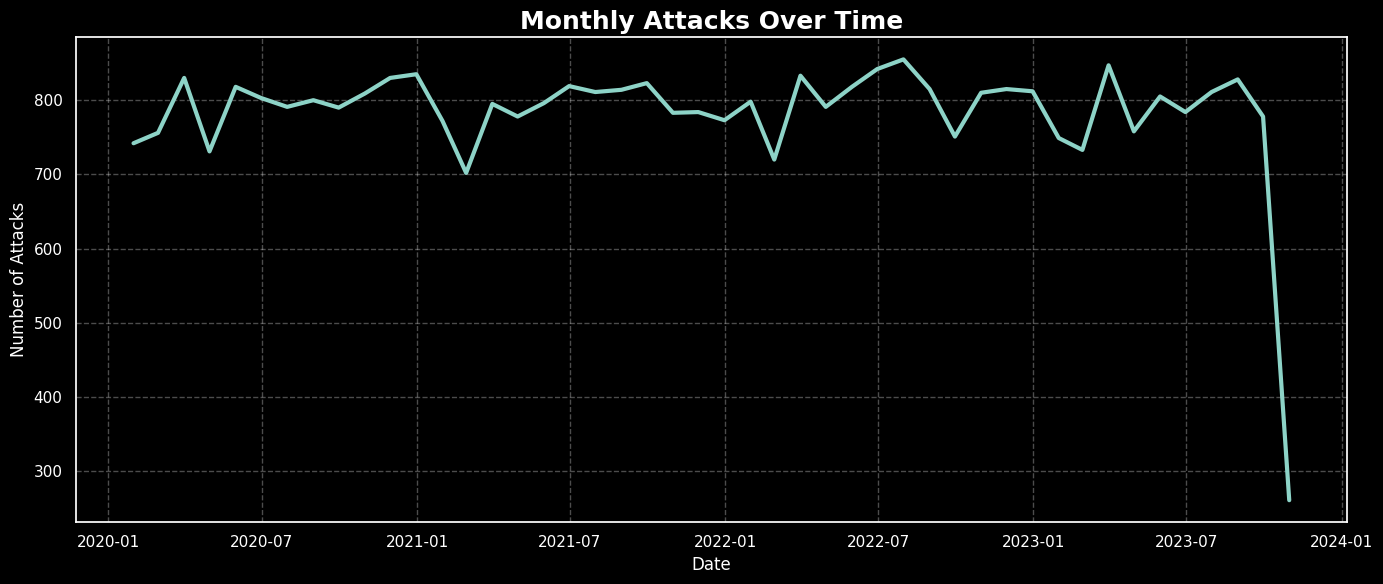

In [82]:
# Convert to datetime properly
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Remove null timestamps
df = df.dropna(subset=["Timestamp"])

# Set index
df = df.set_index("Timestamp")

# Monthly aggregation
time_data = df.resample("M").size()

# Dark theme
plt.style.use("dark_background")

plt.figure(figsize=(14,6))
plt.plot(time_data.index, time_data.values, linewidth=3)

plt.title("Monthly Attacks Over Time", fontsize=18, weight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Attacks")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

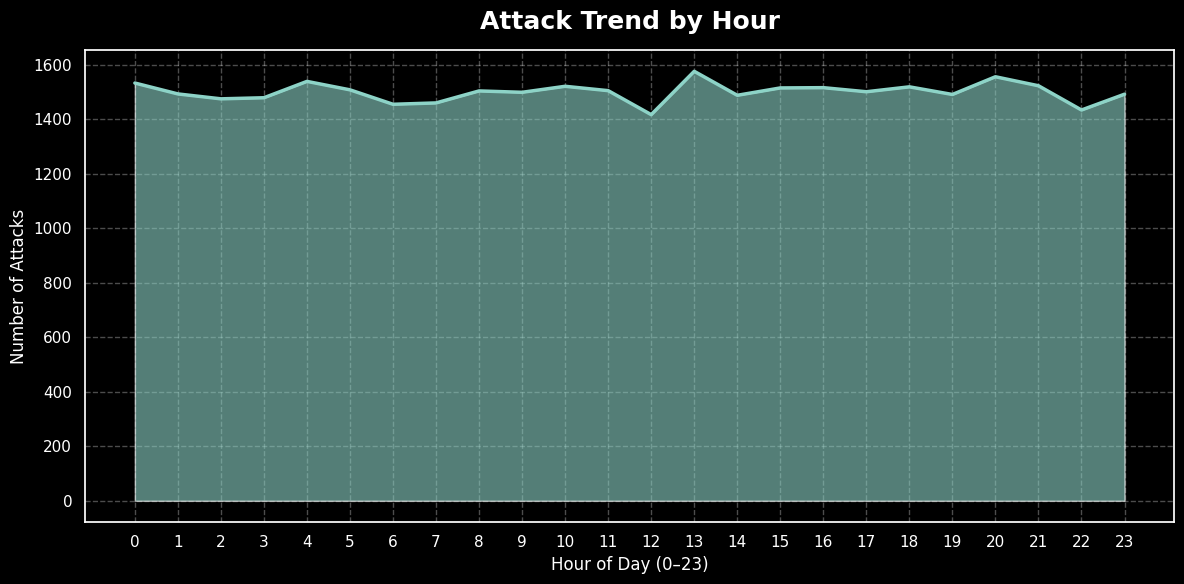

In [83]:
# Dark Theme Area Chart → Attack Trend by Hour
# Count attacks per hour (0–23)
hourly_data = df["Hour"].value_counts().sort_index()

# Dark theme
plt.style.use("dark_background")

plt.figure(figsize=(12,6))

# Area fill
plt.fill_between(hourly_data.index, hourly_data.values, alpha=0.6)

# Line on top
plt.plot(hourly_data.index, hourly_data.values, linewidth=2.5)

# Titles
plt.title("Attack Trend by Hour", fontsize=18, weight="bold", pad=15)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Attacks")

plt.xticks(range(0,24))
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# SLIDE 4 – Response & System Performance

In [85]:
import pandas as pd
import plotly.express as px

# Reload the cleaned data to ensure 'Timestamp' is a column
df = pd.read_csv("cleanned_cybersecurity.csv")

# ----------------------------
# 1️⃣ Convert Timestamp to datetime
# ----------------------------
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# ----------------------------
# 2️⃣ Filter only resolved incidents
# ----------------------------
resolved_df = df[
    df["Action Taken"].isin(["Blocked", "Mitigated", "Closed"])
].copy()

# ----------------------------
# 3️⃣ Create proper Monthly column (datetime format)
# ----------------------------
resolved_df["Month"] = (
    resolved_df["Timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ----------------------------
# 4️⃣ Count incidents per month
# ----------------------------
monthly_closed = (
    resolved_df
    .groupby("Month")
    .size()
    .reset_index(name="Closed Incidents")
    .sort_values("Month")
)

# ----------------------------
# 5️⃣ Add 3-Month Moving Average
# ----------------------------
monthly_closed["3M Moving Avg"] = (
    monthly_closed["Closed Incidents"]
    .rolling(window=3)
    .mean()
)

# ----------------------------
# 6️⃣ Create Line Chart
# ----------------------------
fig = px.line(
    monthly_closed,
    x="Month",
    y=["Closed Incidents", "3M Moving Avg"],
    markers=True,
    title="📈 Incident Resolution Trend (Monthly)",
    template="plotly_dark"
)

# Show every month clearly
fig.update_xaxes(
    dtick="M1",
    tickformat="%b %Y"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Incidents Closed",
    legend_title="Metrics",
    hovermode="x unified"
)

fig.show()

/tmp/ipython-input-2991566207.py:9: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.




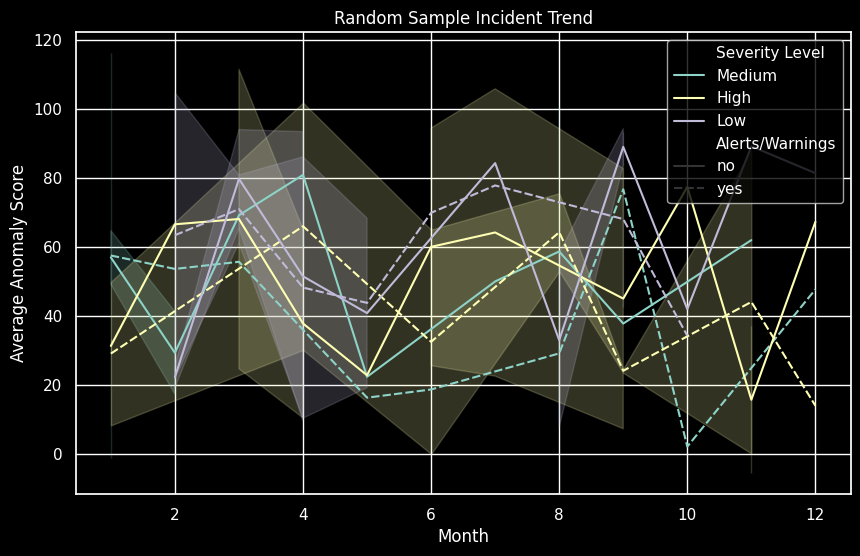

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample 100 rows from the main DataFrame 'df'
sample_df = df.sample(100, random_state=42)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=sample_df,
    x="Month",
    y="Anomaly Scores",
    hue="Severity Level",
    style="Alerts/Warnings",
    ci="sd"
)

plt.title("Random Sample Incident Trend")
plt.xlabel("Month")
plt.ylabel("Average Anomaly Score")
plt.grid(True)
plt.show()

In [ ]:
df.shape

# ML algorithm

# 🌳🌳🌳 Random Forest Classifier and Gradient Boosting Classifier

In this project, we used the Random Forest Classifier as the main machine learning algorithm for Attack Severity (or Attack Type) prediction. Random Forest is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting. Additionally, we also experimented with Gradient Boosting to compare performance and further improve prediction accuracy.

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix


# =========================================
# 3. ENCODE CATEGORICAL COLUMNS
# =========================================
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# =========================================
# 4. CREATE TARGET (BINARY OR MULTI-CLASS)
# =========================================
# Assuming Severity Level: 0 = Low, 1 = Medium, 2 = High

# 👉 Option A: Better Binary (Medium + High = 1, Low = 0)
df['High_Severity'] = df['Severity Level'].apply(lambda x: 0 if x == 0 else 1)

print("\nTarget distribution:")
print(df['High_Severity'].value_counts())

# =========================================
# 5. FEATURES & TARGET
# =========================================
X = df.drop(columns=['Severity Level', 'High_Severity'])
y = df['High_Severity']

# =========================================
# 6. TRAIN–TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 7. RANDOM FOREST MODEL (TUNED)
# =========================================
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# =========================================
# 8. TRAIN RANDOM FOREST
# =========================================
rf.fit(X_train, y_train)

# =========================================
# 9. FEATURE IMPORTANCE SELECTION
# =========================================
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 Important Features:")
print(importances.head(15))

top_features = importances.head(20).index

X2 = df[top_features]
y2 = df['High_Severity']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

# Retrain on selected features
rf.fit(X_train2, y_train2)
y_pred_rf = rf.predict(X_test2)

# =========================================
# 10. EVALUATE RANDOM FOREST
# =========================================
print("\n--- RANDOM FOREST RESULTS ---")
print("Accuracy:", accuracy_score(y_test2, y_pred_rf))
print("F1 Score:", f1_score(y_test2, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test2, y_pred_rf))

# =========================================
# 11. TRY GRADIENT BOOSTING (OPTIONAL BUT STRONG)
# =========================================
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train2, y_train2)
y_pred_gb = gb.predict(X_test2)

print("\n--- GRADIENT BOOSTING RESULTS ---")
print("Accuracy:", accuracy_score(y_test2, y_pred_gb))
print("F1 Score:", f1_score(y_test2, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test2, y_pred_gb))


In [ ]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, r2_score


# ===============================
# 2. LOAD DATASET
# ===============================
df = pd.read_csv("cleanned_cybersecurity.csv")
print("Original Shape:", df.shape)


# ===============================
# 3. TIMESTAMP HANDLING
# ===============================
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.sort_values('Timestamp')

df['Next_Attack_Delta'] = (
    df['Timestamp'].shift(-1) - df['Timestamp']
).dt.total_seconds()

df['Time_Num'] = df['Timestamp'].astype('int64') // 10**9


# ===============================
# 4. DROP NOISY COLUMNS
# ===============================
df.drop(
    columns=['Timestamp', 'Source IP', 'Destination IP', 'Attack ID'],
    inplace=True,
    errors='ignore'
)


# ===============================
# 5. ENCODE CATEGORICAL
# ===============================
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]


# ===============================
# 6. FEATURE ENGINEERING (BIG BOOST)
# ===============================
if {'Total Bytes', 'Duration'}.issubset(df.columns):
    df['Bytes_per_Second'] = df['Total Bytes'] / (df['Duration'] + 1)

if {'Total Packets', 'Duration'}.issubset(df.columns):
    df['Packets_per_Second'] = df['Total Packets'] / (df['Duration'] + 1)

if {'Total Bytes', 'Total Packets'}.issubset(df.columns):
    df['Bytes_per_Packet'] = df['Total Bytes'] / (df['Total Packets'] + 1)


# ===============================
# 7. DROP MISSING
# ===============================
df = df.dropna()
print("Cleaned Shape:", df.shape)


# =====================================================
# 8. ATTACK DETECTION (BINARY → HIGH ACCURACY)
# =====================================================
print("\n--- ATTACK DETECTION (BINARY) ---")

# 0 = Normal, 1 = Attack
df['Is_Attack'] = df['Attack Type'].apply(lambda x: 0 if x == 0 else 1)

X_attack = df.drop(['Attack Type', 'Is_Attack', 'Next_Attack_Delta'], axis=1)
y_attack = df['Is_Attack']

X_train, X_test, y_train, y_test = train_test_split(
    X_attack,
    y_attack,
    test_size=0.2,
    random_state=42,
    stratify=y_attack
)

rf_attack = RandomForestClassifier(
    n_estimators=400,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_attack.fit(X_train, y_train)
y_pred = rf_attack.predict(X_test)

print("Attack Detection Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# =====================================================
# 9. NEXT ATTACK TIME PREDICTION (REGRESSION)
# =====================================================
print("\n--- NEXT ATTACK TIME PREDICTION ---")

X_time = df.drop(columns=['Next_Attack_Delta'], errors='ignore')
y_time = df['Next_Attack_Delta']

X_train, X_test, y_train, y_test = train_test_split(
    X_time,
    y_time,
    test_size=0.2,
    random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

print("MAE (seconds):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
#for map
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------- PAGE CONFIG ----------------
st.set_page_config(
    page_title="Cyber Attack Map",
    layout="wide"
)

st.title("🗺️ Attack Type vs State-wise Distribution (India)")

# ---------------- LOAD DATA ----------------
@st.cache_data
def load_data():
    return pd.read_csv("cleanned_cybersecurity.csv")

df = load_data()

# ---------------- BASIC CLEANING ----------------
df["state"] = (
    df["state"]
    .astype(str)
    .str.strip()
    .str.title()
)

# ---------------- CREATE COUNT ----------------
attack_state_count = (
    df.groupby(["Attack Type", "state"])
      .size()
      .reset_index(name="Count")
)

# ---------------- ATTACK TYPE FILTER ----------------
attack_list = sorted(attack_state_count["Attack Type"].unique())

selected_attack = st.selectbox(
    "🔍 Select Attack Type",
    attack_list
)

# ---------------- FILTER DATA ----------------
filtered_df = attack_state_count[
    attack_state_count["Attack Type"] == selected_attack
]

# ---------------- MAP ----------------
fig = px.choropleth(
    filtered_df,
    geojson="https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson",
    featureidkey="properties.NAME_1",
    locations="state",
    color="Count",
    hover_name="state",
    color_continuous_scale=[
        (0.0, "#ffe6e6"),   # very light red
        (0.5, "#ff4d4d"),   # medium red
        (1.0, "#7f0000")    # dark red
    ],
    range_color=(
        filtered_df["Count"].min(),
        filtered_df["Count"].max()
    ),
    title=f"State-wise Distribution for {selected_attack}"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_traces(
    marker_line_width=0.8,
    marker_line_color="white"
)

# ---------------- SHOW MAP ----------------
st.plotly_chart(fig, use_container_width=True)


In [ ]:
!pip install streamlit pyngrok pandas numpy scikit-learn matplotlib seaborn


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import mean_absolute_error, r2_score

st.set_page_config(page_title="Cybersecurity Dashboard", layout="wide")

# ==============================
# LIVE GIF BACKGROUND
# ==============================
st.markdown(
    """
    <style>
    .stApp {
        background-image: url("https://raw.githubusercontent.com/drashtigadhiya08/space-earth/main/Space%20Earth%20GIF.gif");
        background-size: cover;
        background-position: center;
        background-repeat: no-repeat;
        background-attachment: fixed;
    }
    .stApp::before {
        content: "";
        position: fixed;
        top: 0;
        left: 0;
        width: 100%;
        height: 100%;
        background: rgba(0, 0, 0, 0.6);
        z-index: -1;
    }
    </style>
    """,
    unsafe_allow_html=True
)

# ---------------- SESSION STATE ----------------
if "page" not in st.session_state:
    st.session_state.page = "home"

# =========================
# GLOBAL SIDEBAR NAVIGATION
# =========================
if st.session_state.page != "home":
    st.sidebar.markdown("## 🚀 Navigation")

    if st.sidebar.button("🏠 Home"):
        st.session_state.page = "home"
        st.rerun()

    if st.sidebar.button("📊 Dashboard"):
        st.session_state.page = "dashboard"
        st.rerun()

    if st.sidebar.button("📈 Threat Trends"):
        st.session_state.page = "trends"
        st.rerun()

    if st.sidebar.button("🛡 Risk Engine"):
        st.session_state.page = "risk"
        st.rerun()

    if st.sidebar.button("📡 Real-Time Monitoring"):
        st.session_state.page = "realtime"
        st.rerun()

# =========================
# HOME PAGE
# =========================
if st.session_state.page == "home":
    st.title("🔐 Cybersecurity Attack Information")

    st.markdown("""
    Cybersecurity attacks are malicious activities aimed at disrupting,
    stealing, or damaging digital systems.

    ### Common Attacks
    • DDoS
    • Malware
    • Phishing
    • SQL Injection
    """)

    if st.button("📊 View Dashboard"):
        st.session_state.page = "dashboard"
        st.rerun()

# =========================
# LOAD DATA (COMMON)
# =========================
if st.session_state.page != "home":

    df = pd.read_csv("updated_cybersecurity_attacks.csv")

    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp'])

    df['Year'] = df['Timestamp'].dt.year
    df['Month'] = df['Timestamp'].dt.month
    df['Day'] = df['Timestamp'].dt.day
    df['Hour'] = df['Timestamp'].dt.hour

# =========================
# DASHBOARD PAGE
# =========================
if st.session_state.page == "dashboard":

    st.title("🔐 Cybersecurity Attack Analytics & ML")

    # SIDEBAR FILTERS
    st.sidebar.header("🔎 Filters")

    attack_filter = st.sidebar.selectbox(
        "Attack Type",
        ["All"] + sorted(df["Attack Type"].dropna().unique().tolist())
    )

    severity_filter = st.sidebar.selectbox(
        "Severity Level",
        ["All"] + sorted(df["Severity Level"].dropna().unique().tolist())
    )

    protocol_filter = st.sidebar.selectbox(
        "Protocol",
        ["All"] + sorted(df["Protocol"].dropna().unique().tolist())
    )

    device_filter = st.sidebar.selectbox(
        "Device/OS",
        ["All"] + sorted(df["Device/OS"].dropna().unique().tolist())
    )

    min_p, max_p = int(df["Packet Length"].min()), int(df["Packet Length"].max())
    packet_range = st.sidebar.slider("Packet Length Range", min_p, max_p, (min_p, max_p))

    if attack_filter != "All":
        df = df[df["Attack Type"] == attack_filter]
    if severity_filter != "All":
        df = df[df["Severity Level"] == severity_filter]
    if protocol_filter != "All":
        df = df[df["Protocol"] == protocol_filter]
    if device_filter != "All":
        df = df[df["Device/OS"] == device_filter]

    df = df[df["Packet Length"].between(packet_range[0], packet_range[1])]

    # KPIs
    total_records = len(df)
    unique_attacks = df['Attack Type'].nunique()
    high_sev = df['Severity Level'].isin(['High','Medium']).sum()
    high_sev_pct = round((high_sev / total_records) * 100, 2) if total_records > 0 else 0
    avg_packet = round(pd.to_numeric(df['Packet Length'], errors='coerce').mean(), 2)

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Records", total_records)
    col2.metric("Unique Attacks", unique_attacks)
    col3.metric("High Severity %", f"{high_sev_pct}%")
    col4.metric("Avg Packet Length", avg_packet)

    st.divider()

    # CHARTS
    st.subheader("📊 Attack Visualizations")

    c1, c2 = st.columns(2)
    c3, c4 = st.columns(2)

    with c1:
        fig, ax = plt.subplots()
        sns.violinplot(data=df, x="Attack Type", y="Packet Length", hue="Severity Level", ax=ax)
        st.pyplot(fig)

    with c2:
        fig = sns.lmplot(data=df.sample(min(200,len(df))),
                         x="Packet Length",
                         y="Anomaly Scores",
                         hue="Severity Level",
                         height=4,
                         aspect=1.2)
        st.pyplot(fig)

    with c3:
        fig, ax = plt.subplots()
        sns.boxplot(data=df, x="Packet Length", y="Protocol", ax=ax)
        st.pyplot(fig)

    with c4:
        fig, ax = plt.subplots()
        sns.countplot(data=df, x="Device/OS", hue="Attack Type", ax=ax)
        plt.xticks(rotation=45)
        st.pyplot(fig)

    # HEATMAP
    numeric_cols = [
        'Source Port','Destination Port','Packet Length','Anomaly Scores',
        'Year','Month','Day','Hour'
    ]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    fig, ax = plt.subplots(figsize=(8,4))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", ax=ax)
    st.pyplot(fig)

    # ML MODEL
    st.subheader("🤖 ML Attack Severity Prediction")

    df_ml = df.copy()
    label_encoders = {}

    for col in df_ml.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

    df_ml['High_Severity'] = df_ml['Severity Level'].apply(lambda x: 0 if x == 0 else 1)

    X = df_ml.drop(columns=['Severity Level','High_Severity','Timestamp'])
    y = df_ml['High_Severity']

    X_train, X_test, y_train, y_test = train_test_split(
        X,y,test_size=0.2,random_state=42,stratify=y
    )

    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    st.metric("Model Accuracy", round(accuracy_score(y_test,y_pred),3))
    st.metric("F1 Score", round(f1_score(y_test,y_pred),3))

# =========================
# THREAT TRENDS PAGE
# =========================
if st.session_state.page == "trends":

    st.title("📈 Threat Intelligence Trends")

    st.line_chart(df.groupby("Year")["Attack Type"].count())
    st.bar_chart(df.groupby("Month")["Attack Type"].count())
    st.area_chart(df.groupby("Hour")["Attack Type"].count())

# =========================
# RISK ENGINE PAGE
# =========================
if st.session_state.page == "risk":

    st.title("🛡 Cyber Risk Score Engine")

    df["Risk Score"] = (
        df["Packet Length"] * 0.3 +
        df["Anomaly Scores"] * 0.7
    )

    st.dataframe(df.sort_values("Risk Score", ascending=False).head(20))

# =========================
# REAL-TIME PAGE
# =========================
if st.session_state.page == "realtime":

    st.title("📡 Real-Time Attack Monitoring")

    chart = st.line_chart()

    for i in range(20):
        new_data = pd.DataFrame(
            np.random.randint(1,100,size=(1,1)),
            columns=["Live Threat Score"]
        )
        chart.add_rows(new_data)
        time.sleep(0.3)


In [ ]:
!streamlit run app.py &>/content/logs.txt &


In [ ]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64


In [ ]:
!streamlit run app.py &>/content/logs.txt &


In [ ]:
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501
